### Import libraries

In [2]:
%matplotlib inline
import os
import sys
import csv
import torch
import pathlib
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.cm as cm

### Import Autoencoder class

In [4]:
folder_path = str(pathlib.Path().resolve().parents[0])
print("Folder path =", folder_path)
sys.path.append(folder_path + '/Notebooks/AE_class/')
from Conv_AE_weebots_downsampled import *

Folder path = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder


### Check libraries versions

In [6]:
print(f"torch version: {torch.__version__}")
print(f"numpy version: {np.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"seaborn version: {sb.__version__}")

torch version: 2.2.1+cu121
numpy version: 1.26.4
matplotlib version: 3.8.0
seaborn version: 0.12.2


### Check GPU

In [8]:
print("CUDA is available =", torch.cuda.is_available())
print("CUDA device count =", torch.cuda.device_count())
if torch.cuda.device_count() > 1:
    os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
#print(torch.cuda.current_device())
#print(torch.cuda.device(0))
print("CUDA device name =", torch.cuda.get_device_name(0))

CUDA is available = True
CUDA device count = 2
CUDA device name = NVIDIA RTX A5000


### Hyperparameters

In [10]:
save_plots = False
normalize_ratemaps = False

In [11]:
#Model
n_hidden = 200
batch_size = 256
num_epochs = 100
learning_rate = 1e-4
C_factor = 1e3
alpha = 1e5

#Others
total_experiments = 20
experiment_n = 1 #Start = 1
trial_t = 0

actv_threshold = 0.05

envs = ['Tmaze_0', 'Tmaze_1', 'Tmaze_2']

### Import ratemaps

In [13]:
def update_experiment_ratemaps(exp_n):
    CACHE_DIR = folder_path + "/Models/Exp" + str(exp_n) + "_cache_ratemaps"
    cache_path = os.path.join(CACHE_DIR, f"ratemaps.npy")
    
    arr = np.load(cache_path, mmap_mode="r")  # no full load into RAM
    return arr, CACHE_DIR

arr, CACHE_DIR = update_experiment_ratemaps(experiment_n)

In [14]:
#Normalize ratemaps
def ratemap_normalizer(arr):
    normal_arr = []
    
    for mt in range(len(arr)):
        mt_arr = []
        for unit in range(n_hidden):
            ratemap = arr[mt][unit]
            if np.max(ratemap) != 0.0:
                mt_arr.append(ratemap / np.max(ratemap))
            else:
                mt_arr.append(ratemap)
    
        normal_arr.append(mt_arr)
    
    arr = np.array(normal_arr)

    return arr

if normalize_ratemaps == True:
    arr = ratemap_normalizer(arr)

In [15]:
def load_loss_history(CACHE_DIR):
    loss_csv_filename = CACHE_DIR + '/loss_history.csv'
    
    history_loss = []
    with open(loss_csv_filename, mode='r', newline='') as file:
        reader = csv.DictReader(file)
        for row in reader:
            value = row.get('Image_loss')
            history_loss.append(float(value))
    return history_loss

history_loss = load_loss_history(CACHE_DIR)

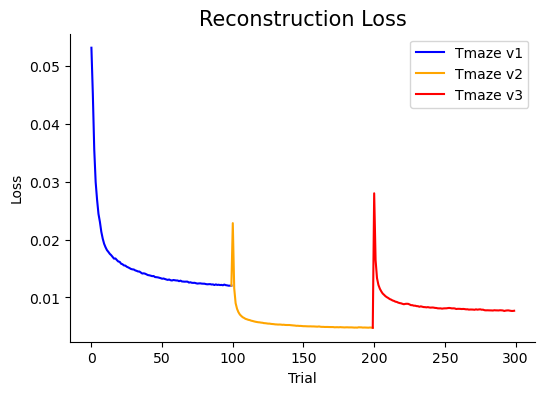

In [16]:
def plot_loss_history(history_loss):
    fig = plt.figure(figsize=(6,4))
    plt.plot(range(0, 100), history_loss[:100], color='blue', label='Tmaze v1')
    plt.plot(range(99, 200), history_loss[99:200], color='orange', label='Tmaze v2')
    plt.plot(range(199, 300), history_loss[199:], color='red', label='Tmaze v3')
    
    plt.xlabel('Trial')
    plt.ylabel('Loss')
    sb.despine()
    plt.legend()
    plt.title('Reconstruction Loss', fontsize=15)
    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/History_loss.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/History_loss.png', format='png')

plot_loss_history(history_loss)

### Explore ratemaps at environment m and trial t

In [18]:
trial_idx = 300
trial_ratemaps = arr[trial_idx]
trial_ratemaps.shape

(200, 50, 50)

In [19]:
plot_ratemaps(trial_ratemaps[:100], 'plot_folder_path', save=False)

In [20]:
peak_activity = []
for i in range(n_hidden):
    peak_activity.append(np.max(arr[trial_idx][i]))

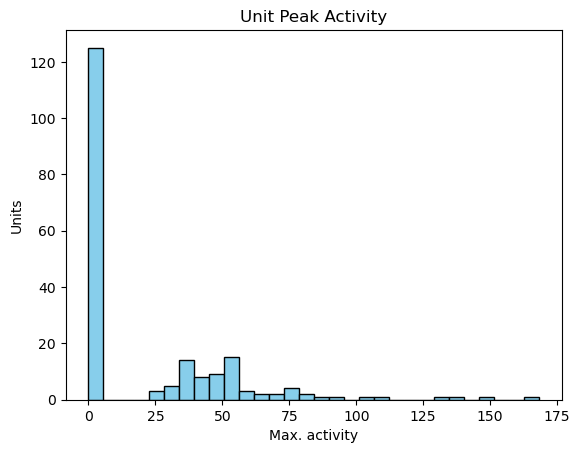

Silent units = 125.0


In [21]:
hist = plt.hist(peak_activity, bins=30, color='skyblue', edgecolor='black')

# Adding labels and title
plt.xlabel('Max. activity')
plt.ylabel('Units')
plt.title('Unit Peak Activity')

# Display the plot
plt.show()

print('Silent units =', hist[0][0])

## Metrics Functions

In [23]:
def get_num_active_units(ratemaps, actv_threshold):
    active_units = 0
    for i in range(len(ratemaps)):
        peak = np.max(ratemaps[i])
        if peak > actv_threshold:
            active_units += 1
    return active_units
#####################################################################    

def get_max_coverage(ratemaps, actv_threshold):
    #TDefine maximal firing coverage once, at the first trial of the first environment
    max_size = 0
    
    for i in range(len(ratemaps)):
        size = np.sum(ratemaps[i] > actv_threshold)
        if size > max_size:
            max_size = size

    return max_size
#####################################################################

def get_mean_unit_coverage_at_t(ratemaps, max_coverage, actv_threshold):
    #Normalize the activation coverage of each unit.
    unit_coverage = []
    
    for i in range(len(ratemaps)):
        unit_coverage.append(np.sum(ratemaps[i] > actv_threshold) / max_coverage)

    # Define mean unit coverage of (only) active units
    mean_unit_coverage = np.mean([x for x in unit_coverage if x != 0.0])
    
    return mean_unit_coverage
#####################################################################

def representative_unit_sums(ratemaps):
    #Take 4 reference points for measuring summed activity at representative locations
    top_left_unit_sum = np.sum(ratemaps[:, 40, 10])
    top_center_unit_sum = np.sum(ratemaps[:, 40, 25])
    top_right_unit_sum = np.sum(ratemaps[:, 40, 40])
    bottom_center_unit_sum = np.sum(ratemaps[:, 10, 25])
    return top_left_unit_sum, top_center_unit_sum, top_right_unit_sum, bottom_center_unit_sum
#####################################################################

def representative_unit_count(ratemaps, actv_threshold):
    #Take 4 reference points for measuring the number of active units at representative locations
    top_left_unit_count = np.sum(ratemaps[:, 40, 10] > actv_threshold)
    top_center_unit_count = np.sum(ratemaps[:, 40, 25] > actv_threshold)
    top_right_unit_count = np.sum(ratemaps[:, 40, 40] > actv_threshold)
    bottom_center_unit_count = np.sum(ratemaps[:, 10, 25] > actv_threshold)
    return top_left_unit_count, top_center_unit_count, top_right_unit_count, bottom_center_unit_count
#####################################################################

def compute_mean_std(data):
    arr = np.array(data)        # shape (15, 301)
    mean = arr.mean(axis=0)     # shape (301,)
    std  = arr.std(axis=0)      # shape (301,)
    return mean, std

## Plotting functions

In [25]:
def hide_ticks(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

#####################################################################################################

def add_colorbar(ax, im):
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Adjust fraction & pad for size and spacing
    cbar.ax.tick_params(labelsize=8)  # Adjust tick label size

#####################################################################################################

def plot_loss_history(mean, std, figsize=(6,4), save_plots=False, plot_folder_path=''):
    fig = plt.figure(figsize=figsize)

    segments = [
        (range(0, num_epochs), mean[0:num_epochs], std[0:num_epochs], 'blue', 'Tmaze v1'),
        (range(num_epochs-1, (num_epochs*2)),  mean[num_epochs-1:(num_epochs*2)], std[num_epochs-1:(num_epochs*2)], 'orange', 'Tmaze v2'),
        (range((num_epochs*2)-1, (num_epochs*3)), mean[(num_epochs*2)-1:], std[(num_epochs*2)-1:], 'red', 'Tmaze v3'),
    ]

    for x, m, s, color, label in segments:
        x = list(x)
        plt.plot(x, m, color=color, label=label)
        plt.fill_between(x, m - s, m + s, alpha=0.25, color=color)

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    sb.despine()
    plt.legend()
    plt.title('Mean Reconstruction Loss', fontsize=15)
    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/History_loss.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/History_loss.png', format='png')
        
#####################################################################################################

def plot_loss_history_by_experiment(all_history_loss, figsize=(6,4)):
    fig, ax = plt.subplots(figsize=figsize)
    
    mean, std = compute_mean_std(all_history_loss)
    timesteps = np.arange(300)
    colors = cm.tab20.colors 
    
    # Individual series
    for i, series in enumerate(all_history_loss):
        ax.plot(timesteps, series, color=colors[i], linewidth=0.8, alpha=0.8)
    
    # Mean and std envelope
    ax.plot(timesteps, mean, color="green", linewidth=2.5, label="Mean", zorder=5)
    ax.fill_between(timesteps, mean - std, mean + std,
                    alpha=0.25, color="green", label="±1 std")
    
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Loss", fontsize=12)
    ax.set_title("Mean Reconstruction Loss by Experiment", fontsize=14, fontweight="bold")
    ax.legend(fontsize=10, framealpha=0.7)
    ax.grid(True, linestyle="--", alpha=0.3)
    
    plt.tight_layout()
    plt.show()

#####################################################################################################

def plot_unit_coverage(mean, std, figsize=(6,4), save_plots=False, plot_folder_path=''):
    fig = plt.figure(figsize=figsize)

    segments = [
        (range(1, num_epochs+2), mean[1:num_epochs+2], std[1:num_epochs+2], 'blue', 'Tmaze v1'),
        (range(num_epochs+1, (num_epochs*2)+2),  mean[num_epochs+1:(num_epochs*2)+2], std[num_epochs+1:(num_epochs*2)+2], 'orange', 'Tmaze v2'),
        (range((num_epochs*2)+1, (num_epochs*3)+1), mean[(num_epochs*2)+1:], std[(num_epochs*2)+1:], 'red', 'Tmaze v3'),
    ]

    for x, m, s, color, label in segments:
        x = list(x)
        plt.plot(x, m, color=color, label=label)
        plt.fill_between(x, m - s, m + s, alpha=0.25, color=color)

    plt.scatter(range(0, 1), mean[:1], color='black', label='Pre', s=25)

    plt.xlabel('Epoch')
    plt.ylabel('Coverage (%)')
    sb.despine()
    plt.legend()
    plt.title('Mean Unit Coverage', fontsize=15)
    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/Unit_coverage.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/Unit_coverage.png', format='png')

#####################################################################################################

def plot_unit_coverage_by_experiment(all_mean_unit_coverage, figsize=(16, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    
    mean, std = compute_mean_std(all_mean_unit_coverage)
    timesteps = np.arange(301)
    colors = cm.tab20.colors 
    
    # Individual series
    for i, series in enumerate(all_mean_unit_coverage):
        ax.plot(timesteps, series, color=colors[i], linewidth=0.8, alpha=0.8)
    
    # Mean and std envelope
    ax.plot(timesteps, mean, color="green", linewidth=2.5, label="Mean", zorder=5)
    ax.fill_between(timesteps, mean - std, mean + std,
                    alpha=0.25, color="green", label="±1 std")
    
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Coverage %", fontsize=12)
    ax.set_title("Mean Unit Coverage by Experiment", fontsize=14, fontweight="bold")
    ax.legend(fontsize=10, framealpha=0.7)
    ax.grid(True, linestyle="--", alpha=0.3)
    
    plt.tight_layout()
    plt.show()

#####################################################################################################

def plot_active_units_count(mean, std, figsize=(6,4), save_plots=False, plot_folder_path=''):
    fig = plt.figure(figsize=figsize)

    segments = [
        (range(1, num_epochs+2), mean[1:num_epochs+2], std[1:num_epochs+2], 'blue', 'Tmaze v1'),
        (range(num_epochs+1, (num_epochs*2)+2),  mean[num_epochs+1:(num_epochs*2)+2], std[num_epochs+1:(num_epochs*2)+2], 'orange', 'Tmaze v2'),
        (range((num_epochs*2)+1, (num_epochs*3)+1), mean[(num_epochs*2)+1:], std[(num_epochs*2)+1:], 'red', 'Tmaze v3'),
    ]

    for x, m, s, color, label in segments:
        x = list(x)
        plt.plot(x, m, color=color, label=label)
        plt.fill_between(x, m - s, m + s, alpha=0.25, color=color)

    plt.scatter(range(0, 1), mean[:1], color='black', label='Pre', s=25)

    plt.xlabel('Epoch')
    plt.ylabel('Units (out of 200)')
    sb.despine()
    plt.legend()
    plt.title('Active units count', fontsize=15)
    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/Active_units.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/Active_units.png', format='png')

#####################################################################################################

def plot_active_units_count_by_experiment(all_num_active_units, figsize=(16, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    
    mean, std = compute_mean_std(all_num_active_units)
    timesteps = np.arange(301)
    colors = cm.tab20.colors 
    
    # Individual series
    for i, series in enumerate(all_num_active_units):
        ax.plot(timesteps, series, color=colors[i], linewidth=0.8, alpha=0.8)
    
    # Mean and std envelope
    ax.plot(timesteps, mean, color="green", linewidth=2.5, label="Mean", zorder=5)
    ax.fill_between(timesteps, mean - std, mean + std,
                    alpha=0.25, color="green", label="±1 std")
    
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Units (out of 200)", fontsize=12)
    ax.set_title("Mean Number of Active Units by Experiment", fontsize=14, fontweight="bold")
    ax.legend(fontsize=10, framealpha=0.7)
    ax.grid(True, linestyle="--", alpha=0.3)
    
    plt.tight_layout()
    plt.show()

#####################################################################################################

def plot_activity_rep_loc(all_BC_rep_unit_sum_history, all_TL_rep_unit_sum_history, all_TC_rep_unit_sum_history, all_TR_rep_unit_sum_history, figsize=(6,4), save_plots=False, plot_folder_path=''):
    BC_mean, BC_std = compute_mean_std(all_BC_rep_unit_sum_history)
    TL_mean, TL_std = compute_mean_std(all_TL_rep_unit_sum_history)
    TC_mean, TC_std = compute_mean_std(all_TC_rep_unit_sum_history)
    TR_mean, TR_std = compute_mean_std(all_TR_rep_unit_sum_history)

    timesteps = np.arange(len(all_BC_rep_unit_sum_history[0]))
    
    
    fig = plt.figure(figsize=figsize)

    plt.plot(BC_mean[1:], label='Bottom-Center', color='#1f77b4')
    plt.fill_between(timesteps, BC_mean - BC_std, BC_mean + BC_std, alpha=0.25, color="#1f77b4")
    plt.plot(TL_mean[1:], label='Top-Left', color='#ff7f0e')
    plt.fill_between(timesteps, TL_mean - TL_std, TL_mean + TL_std, alpha=0.25, color="#ff7f0e")
    plt.plot(TC_mean[1:], label='Top-Center', color='#2ca02c')
    plt.fill_between(timesteps, TC_mean - TC_std, TC_mean + TC_std, alpha=0.25, color="#2ca02c")
    plt.plot(TR_mean[1:], label='Top-Right', color='#d62728')
    plt.fill_between(timesteps, TR_mean - TR_std, TR_mean + TR_std, alpha=0.25, color="#d62728", label="±1 std")
    plt.scatter(range(0, 1), BC_mean[:1], color='#1f77b4', s=15)
    plt.scatter(range(0, 1), TL_mean[:1], color='#ff7f0e', s=15)
    plt.scatter(range(0, 1), TC_mean[:1], color='#2ca02c', s=15)
    plt.scatter(range(0, 1), TR_mean[:1], color='#d62728', s=15)
    
    
    plt.xlabel('Epoch')
    plt.ylabel('Sum activity')
    sb.despine()
    plt.title('Sum actv. at representative locations', fontsize=15)
    plt.legend()
    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/Rep_locations.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/Rep_locations.png', format='png')
        
#####################################################################################################

def plot_units_rep_loc(all_BC_rep_unit_count_history, all_TL_rep_unit_count_history, all_TC_rep_unit_count_history, all_TR_rep_unit_count_history, figsize=(6,4), save_plots=False, plot_folder_path=''):
    BC_mean, BC_std = compute_mean_std(all_BC_rep_unit_count_history)
    TL_mean, TL_std = compute_mean_std(all_TL_rep_unit_count_history)
    TC_mean, TC_std = compute_mean_std(all_TC_rep_unit_count_history)
    TR_mean, TR_std = compute_mean_std(all_TR_rep_unit_count_history)

    timesteps = np.arange(len(all_BC_rep_unit_count_history[0]))
    fig = plt.figure(figsize=figsize)

    plt.plot(BC_mean[1:], label='Bottom-Center', color='#1f77b4')
    plt.fill_between(timesteps, BC_mean - BC_std, BC_mean + BC_std, alpha=0.25, color="#1f77b4")
    plt.plot(TL_mean[1:], label='Top-Left', color='#ff7f0e')
    plt.fill_between(timesteps, TL_mean - TL_std, TL_mean + TL_std, alpha=0.25, color="#ff7f0e")
    plt.plot(TC_mean[1:], label='Top-Center', color='#2ca02c')
    plt.fill_between(timesteps, TC_mean - TC_std, TC_mean + TC_std, alpha=0.25, color="#2ca02c")
    plt.plot(TR_mean[1:], label='Top-Right', color='#d62728')
    plt.fill_between(timesteps, TR_mean - TR_std, TR_mean + TR_std, alpha=0.25, color="#d62728", label="±1 std")
    plt.scatter(range(0, 1), BC_mean[:1], color='#1f77b4', s=15)
    plt.scatter(range(0, 1), TL_mean[:1], color='#ff7f0e', s=15)
    plt.scatter(range(0, 1), TC_mean[:1], color='#2ca02c', s=15)
    plt.scatter(range(0, 1), TR_mean[:1], color='#d62728', s=15)
    
    
    plt.xlabel('Epoch')
    plt.ylabel('Freq.')
    sb.despine()
    plt.title('Active units at representative locations', fontsize=15)
    plt.legend()
    plt.show()
        
#####################################################################################################

def plot_cogmap_correlation(mean, std, figsize=(6,4), save_plots=False, plot_folder_path=''):
    fig = plt.figure(figsize=figsize)

    segments = [
        (range(1, num_epochs), mean[1:num_epochs], std[1:num_epochs], 'blue', 'Tmaze v1'),
        (range(num_epochs-1, (num_epochs*2)),  mean[num_epochs-1:(num_epochs*2)], std[num_epochs-1:(num_epochs*2)], 'orange', 'Tmaze v2'),
        (range((num_epochs*2)-1, (num_epochs*3)), mean[(num_epochs*2)-1:], std[(num_epochs*2)-1:], 'red', 'Tmaze v3'),
    ]

    for x, m, s, color, label in segments:
        x = list(x)
        plt.plot(x, m, color=color, label=label)
        plt.fill_between(x, m - s, m + s, alpha=0.25, color=color)

    plt.scatter(range(0, 1), mean[:1], color='black', label='Pre', s=25)

    plt.xlabel('Epoch')
    plt.ylabel('Pearson Correlation')
    sb.despine()
    plt.legend(loc=4)
    plt.title('Cog. Maps Similarity (t vs. t–1)', fontsize=15)
    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/Map_similarity.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/Map_similarity.png', format='png')

#####################################################################################################

def plot_cogmap_correlation_by_experiment(all_correlation_history, figsize=(16, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    
    mean, std = compute_mean_std(all_correlation_history)
    timesteps = np.arange(300)
    colors = cm.tab20.colors 
    
    # Individual series
    for i, series in enumerate(all_correlation_history):
        ax.plot(timesteps, series, color=colors[i], linewidth=0.8, alpha=0.8)
    
    # Mean and std envelope
    ax.plot(timesteps, mean, color="green", linewidth=2.5, label="Mean", zorder=5)
    ax.fill_between(timesteps, mean - std, mean + std,
                    alpha=0.25, color="green", label="±1 std")
    
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Pearson Correlation", fontsize=12)
    ax.set_title('Cog. Maps Similarity by Experiments(t vs. t–1)', fontsize=14, fontweight="bold")
    ax.legend(fontsize=10, framealpha=0.7)
    ax.grid(True, linestyle="--", alpha=0.3)
    
    plt.tight_layout()
    plt.show()

#####################################################################################################

def plot_img_reconstruction(input_img, mt0, mt50, mt100, figsize=(14,3), m0_bool=False, save_plots=False, plot_folder_path=''):

    fig = plt.figure(figsize=figsize)
    plt.subplot(141)
    plt.imshow(input_img)
    plt.suptitle('Image reconstruction', fontsize=15)
    plt.title('Input', fontsize=10)
    plt.ylabel('Tmaze v3')
    
    plt.subplot(142)
    plt.imshow(predict(input_img, mt0))
    if m0_bool == True:
        plt.title('Trial 0', fontsize=10)
    else:
        plt.title('Trial 1', fontsize=10)

    plt.subplot(143)
    plt.imshow(predict(input_img, mt50))
    plt.title('Trial 50', fontsize=10)

    plt.subplot(144)
    plt.imshow(predict(input_img, mt100))
    plt.title('Trial 100', fontsize=10)

    plt.show()
    
    if save_plots == True:
        fig.savefig(plot_folder_path + '/Tmaze3_img_recon.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/Tmaze3_img_recon.png', format='png')

#####################################################################################################

def plot_example_ratemaps_progress(example_units, example_ratemaps, figsize=(15, 8), save_plots=False, plot_folder_path=''):
    
    fig, axes = plt.subplots(5, 9, figsize=figsize)
    colors = ['blue'] * 3 + ['orange'] * 3 + ['red'] * 3
    ts = ['0', '10', '100', '1', '10', '100', '1', '10', '100']

    for i, ax in enumerate(axes.flatten()):
        # Determine the column index (0–8)
        col = i % 9
        color = colors[col]
    
        # Draw dashed T-maze using the color for this column
        ax.axhline(y=35, xmin=0, xmax=0.3, color=color, linestyle='--', linewidth=2)
        ax.axhline(y=35, xmin=0.7, xmax=1, color=color, linestyle='--', linewidth=2)
        ax.axhline(y=49, xmin=0, xmax=1, color=color, linestyle='--', linewidth=2)
        ax.axhline(y=0, xmin=0.3, xmax=0.7, color=color, linestyle='--', linewidth=2)
        ax.axvline(x=35, ymin=0, ymax=0.7, color=color, linestyle='--', linewidth=2)
        ax.axvline(x=15, ymin=0, ymax=0.7, color=color, linestyle='--', linewidth=2)
        ax.axvline(x=0, ymin=0.7, ymax=1, color=color, linestyle='--', linewidth=2)
        ax.axvline(x=49, ymin=0.7, ymax=1, color=color, linestyle='--', linewidth=2)
    
    for mt in range(len(example_ratemaps)):
        for unit in range(len(example_ratemaps[mt])):
            im = axes[unit, mt].imshow(example_ratemaps[mt][unit], cmap='hot', origin='lower')
            hide_ticks(axes[unit, mt])
            if mt == 0: axes[unit, mt].set_ylabel("Unit " + str(example_units[unit]), fontsize=15, labelpad=10)
            if unit == 0: axes[unit, mt].set_title('T' + ts[mt], fontsize=15)

    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/example_units.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/example_units.png', format='png')

## Model update functions

In [27]:
def format_dataset(env):
    data_path = folder_path + '/Datasets/' + env
    csv_filename = data_path + "/data.csv"

    img_filename_list = os.listdir(data_path)
    num_images = len(img_filename_list) -1 

    return data_path, csv_filename, num_images

#####################################################################

def Load_env_dataset(env_idx):
    # Load dataset every T-maze version
    env = envs[env_idx] #Choose environment index
    data_path, csv_filename, num_images = format_dataset(env)

    print("Dataset Path =", data_path)
    print("Num. Images in Dataset =", num_images)
    
    dataset = load_dataset(data_path)  # this array should have shape (n_samples, 3, 120, 160)

    return dataset, csv_filename
    
#####################################################################

def update_model_trial(experiment_n, env_idx, trial):
    # Update model name for trial t
    env = envs[env_idx]
    trial_t = trial
    model_filename =  env + '-Trial' + str(trial_t) + 'of' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate) + '.pth'
    foldername = 'Exp' + str(experiment_n) + '-NEpisodes' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate)

    model_folder_path = folder_path + '/Models/' + foldername
    model_path = model_folder_path + '/' + model_filename
    #print('Model loaded =', model_filename)

    model = Conv_AE(n_hidden=n_hidden)
    model.load_state_dict(torch.load(model_path))

    return model

## Data processing loop

In [29]:
all_history_loss = []
all_num_active_units = []
all_mean_unit_coverage_history = []
all_correlation_history = []

all_TL_rep_unit_sum_history = []
all_TC_rep_unit_sum_history = []
all_TR_rep_unit_sum_history = []
all_BC_rep_unit_sum_history = []

all_TL_rep_unit_count_history = []
all_TC_rep_unit_count_history = []
all_TR_rep_unit_count_history = []
all_BC_rep_unit_count_history = []


for i in range(total_experiments):
    
    arr, CACHE_DIR = update_experiment_ratemaps(experiment_n + i)
    history_loss = load_loss_history(CACHE_DIR)

    if normalize_ratemaps == True:
        print('Normalizing ratemaps for experiment', str(experiment_n + i))
        arr = ratemap_normalizer(arr)
    else:
        print('Importing ratemaps from experiment', str(experiment_n + i))

    num_active_units = []
    mean_unit_coverage_history = []
    correlation_history = []
    
    TL_rep_unit_sum_history = []
    TC_rep_unit_sum_history = []
    TR_rep_unit_sum_history = []
    BC_rep_unit_sum_history = []
    
    TL_rep_unit_count_history = []
    TC_rep_unit_count_history = []
    TR_rep_unit_count_history = []
    BC_rep_unit_count_history = []

    for t in range(arr.shape[0]):
        if t == 0:
            max_coverage = get_max_coverage(arr[t], actv_threshold)
        
        num_active_units.append(get_num_active_units(arr[t], actv_threshold))
        mean_unit_coverage_history.append(get_mean_unit_coverage_at_t(arr[t], max_coverage, actv_threshold))
    
        # Unit activity at representative locations
        TL_sum, TC_sum, TR_sum, BC_sum = representative_unit_sums(arr[t])
        TL_rep_unit_sum_history.append(TL_sum)
        TC_rep_unit_sum_history.append(TC_sum)
        TR_rep_unit_sum_history.append(TR_sum)
        BC_rep_unit_sum_history.append(BC_sum)
        
        TL_count, TC_count, TR_count, BC_count = representative_unit_count(arr[t], actv_threshold)
        TL_rep_unit_count_history.append(TL_count)
        TC_rep_unit_count_history.append(TC_count)
        TR_rep_unit_count_history.append(TR_count)
        BC_rep_unit_count_history.append(BC_count)
    
        # Measure map correlation
        if t != 0:
            flat_t0 = prev_ratemaps.flatten()
            flat_t1 = arr[t].flatten()
            corr = np.corrcoef(flat_t0, flat_t1)[0, 1]
            correlation_history.append(corr)
    
        prev_ratemaps = arr[t]

    all_history_loss.append(history_loss)
    all_num_active_units.append(num_active_units)
    all_mean_unit_coverage_history.append(mean_unit_coverage_history)
    all_correlation_history.append(correlation_history)
    all_TL_rep_unit_sum_history.append(TL_rep_unit_sum_history)
    all_TC_rep_unit_sum_history.append(TC_rep_unit_sum_history)
    all_TR_rep_unit_sum_history.append(TR_rep_unit_sum_history)
    all_BC_rep_unit_sum_history.append(BC_rep_unit_sum_history)
    all_TL_rep_unit_count_history.append(TL_rep_unit_count_history)
    all_TC_rep_unit_count_history.append(TC_rep_unit_count_history)
    all_TR_rep_unit_count_history.append(TR_rep_unit_count_history)
    all_BC_rep_unit_count_history.append(BC_rep_unit_count_history)

Importing ratemaps from experiment 1
Importing ratemaps from experiment 2
Importing ratemaps from experiment 3
Importing ratemaps from experiment 4
Importing ratemaps from experiment 5
Importing ratemaps from experiment 6
Importing ratemaps from experiment 7
Importing ratemaps from experiment 8
Importing ratemaps from experiment 9
Importing ratemaps from experiment 10
Importing ratemaps from experiment 11
Importing ratemaps from experiment 12
Importing ratemaps from experiment 13
Importing ratemaps from experiment 14
Importing ratemaps from experiment 15
Importing ratemaps from experiment 16
Importing ratemaps from experiment 17
Importing ratemaps from experiment 18
Importing ratemaps from experiment 19
Importing ratemaps from experiment 20


In [30]:
all_mean_unit_coverage = []
for i in range(total_experiments):
    all_mean_unit_coverage.append([x * 100 for x in all_mean_unit_coverage_history[i]])

In [31]:
len(all_history_loss[0])

300

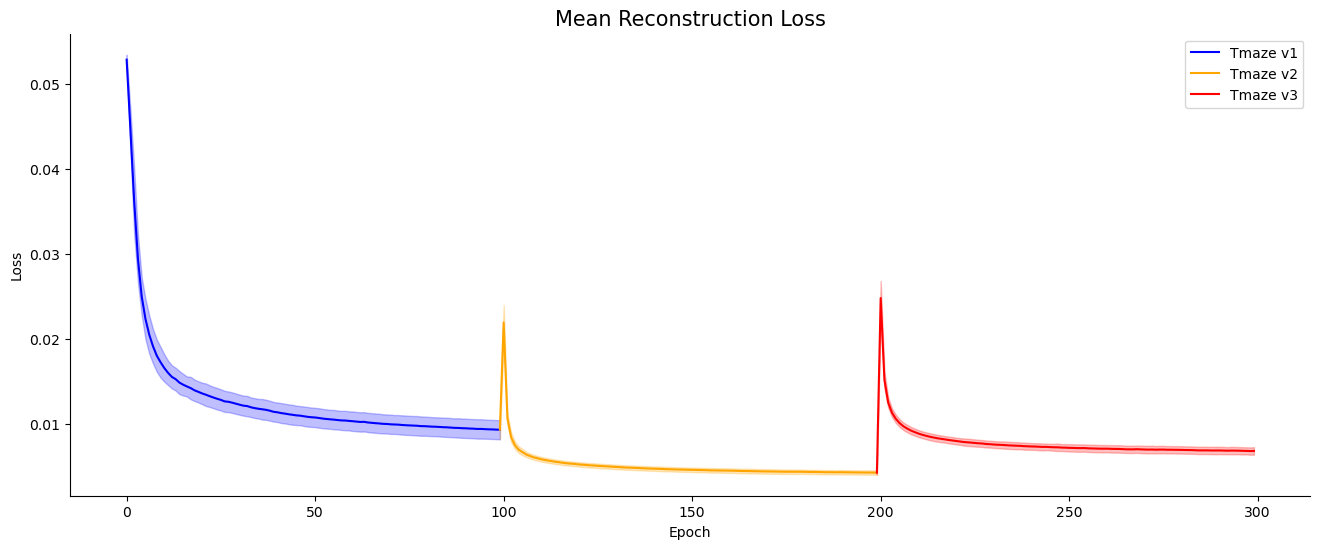

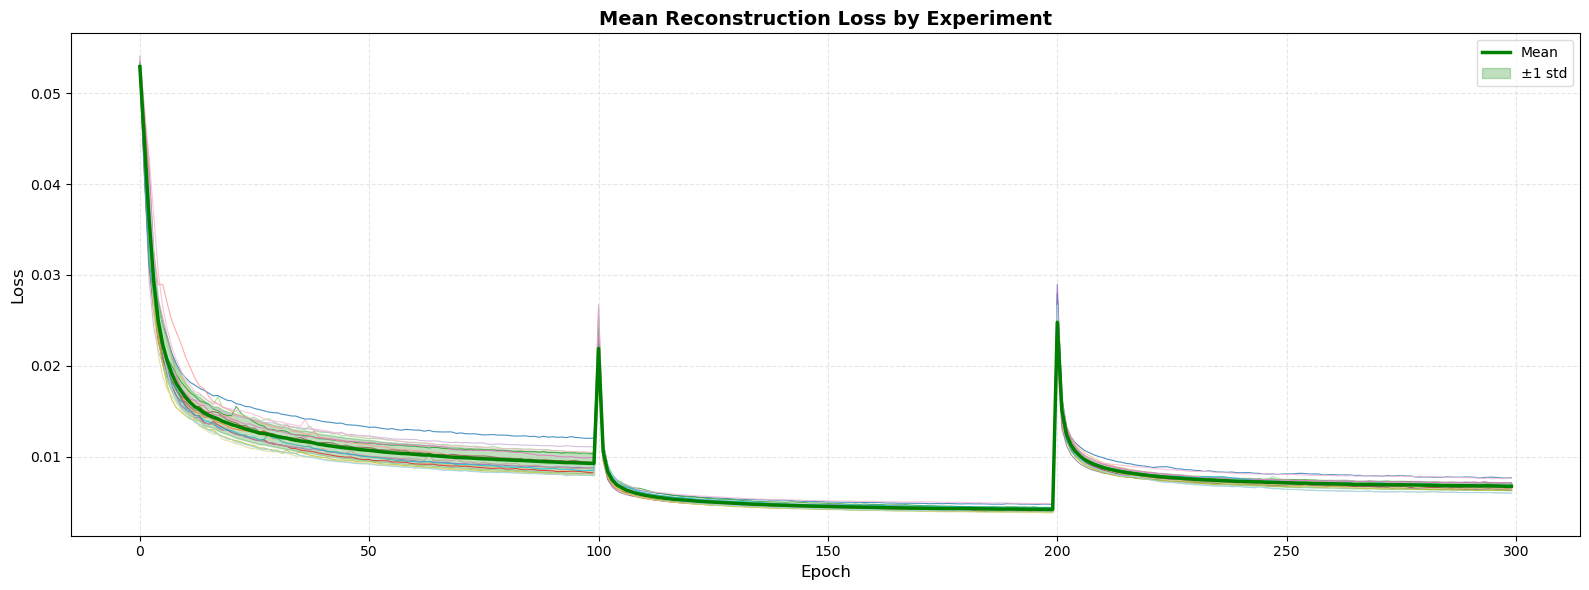

In [32]:
loss_mean, loss_std = compute_mean_std(all_history_loss)
plot_loss_history(loss_mean, loss_std, figsize=(16,6))
plot_loss_history_by_experiment(all_history_loss, figsize=(16,6))

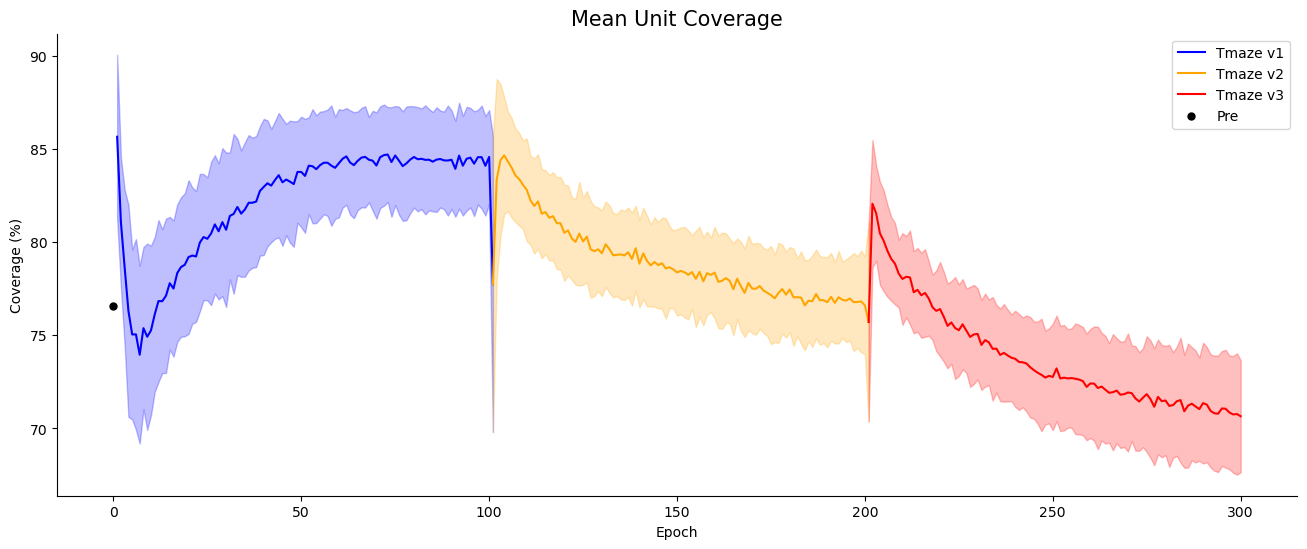

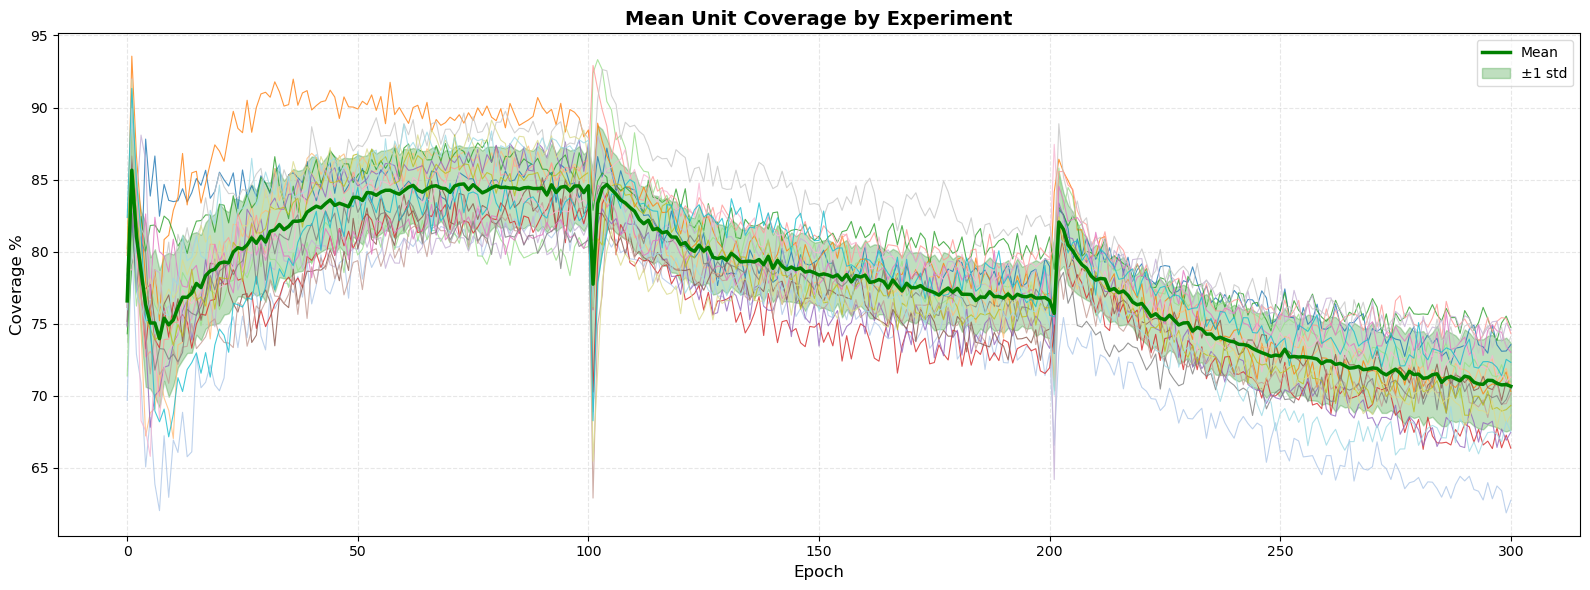

In [33]:
coverage_mean, coverage_std = compute_mean_std(all_mean_unit_coverage)
plot_unit_coverage(coverage_mean, coverage_std, figsize=(16,6))
plot_unit_coverage_by_experiment(all_mean_unit_coverage, figsize=(16,6))

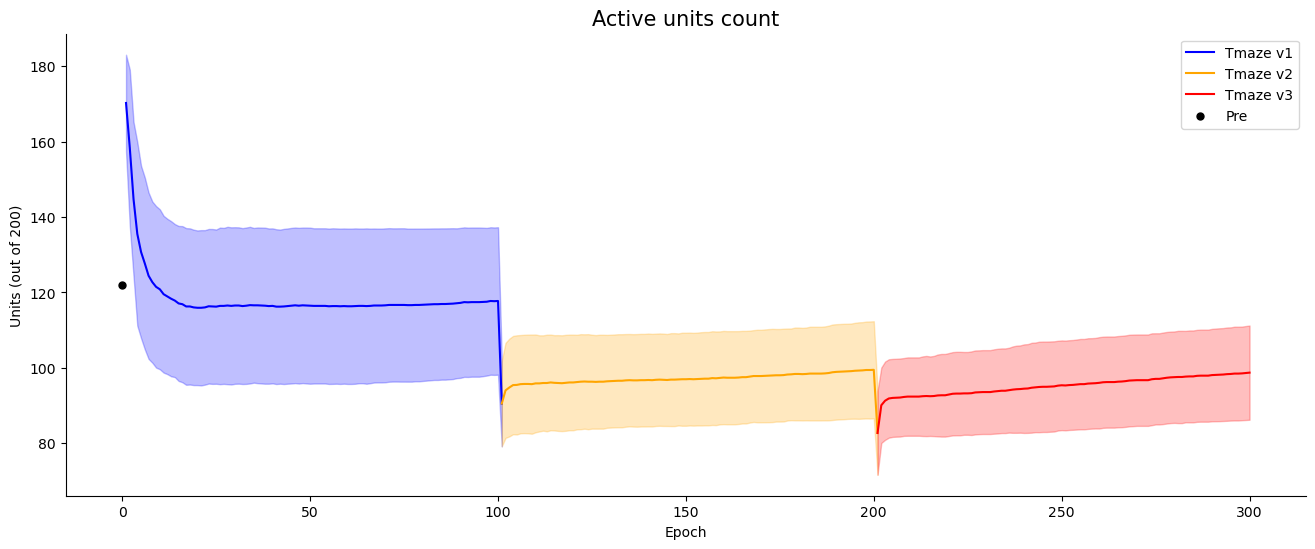

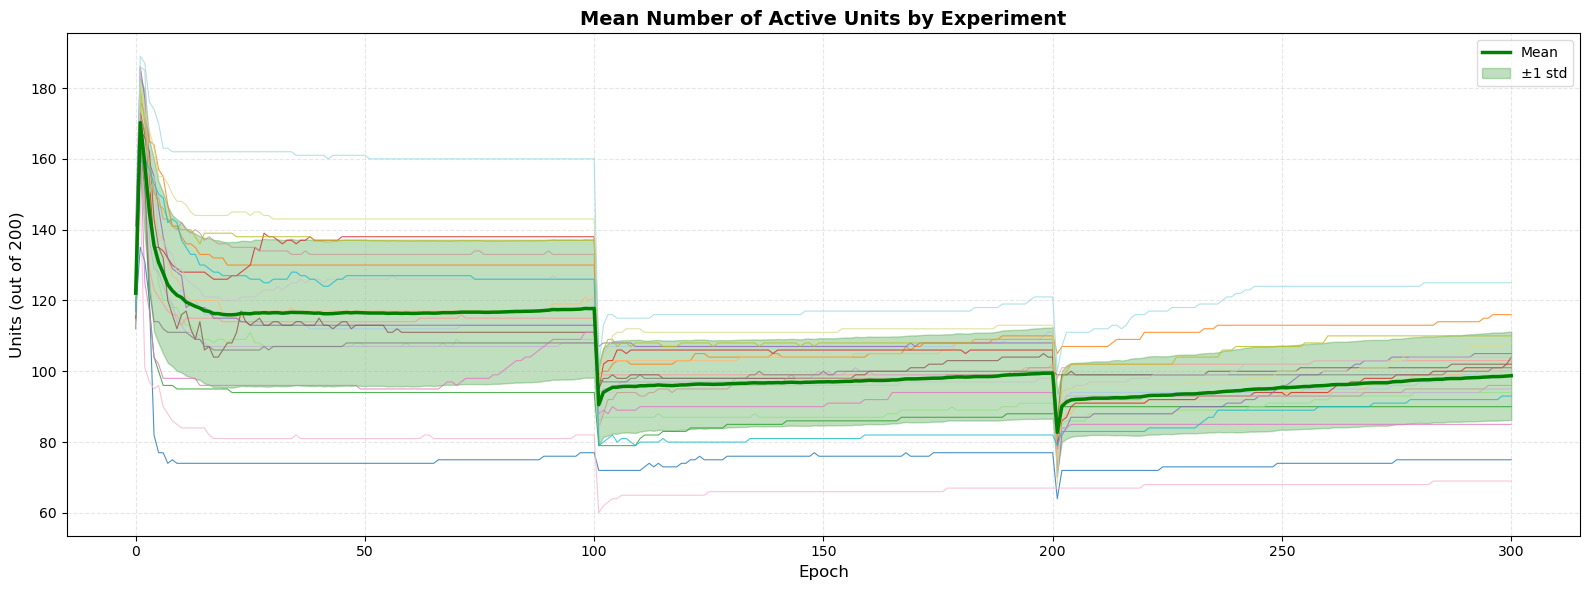

In [34]:
active_units_mean, active_units_std = compute_mean_std(all_num_active_units)
plot_active_units_count(active_units_mean, active_units_std, figsize=(16,6))
plot_active_units_count_by_experiment(all_num_active_units, figsize=(16,6))

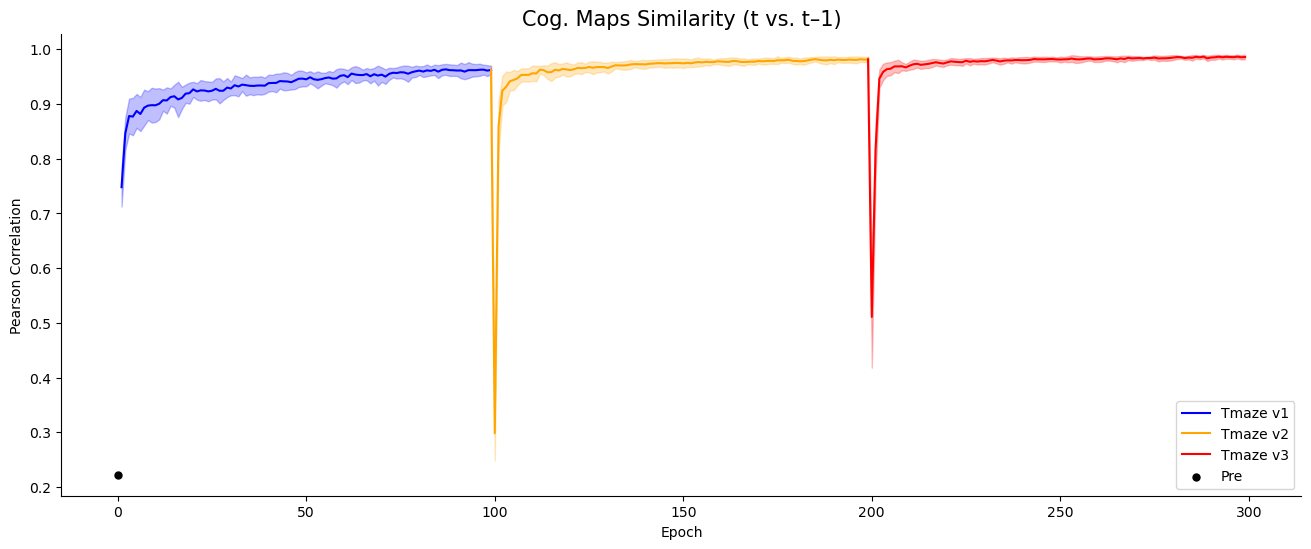

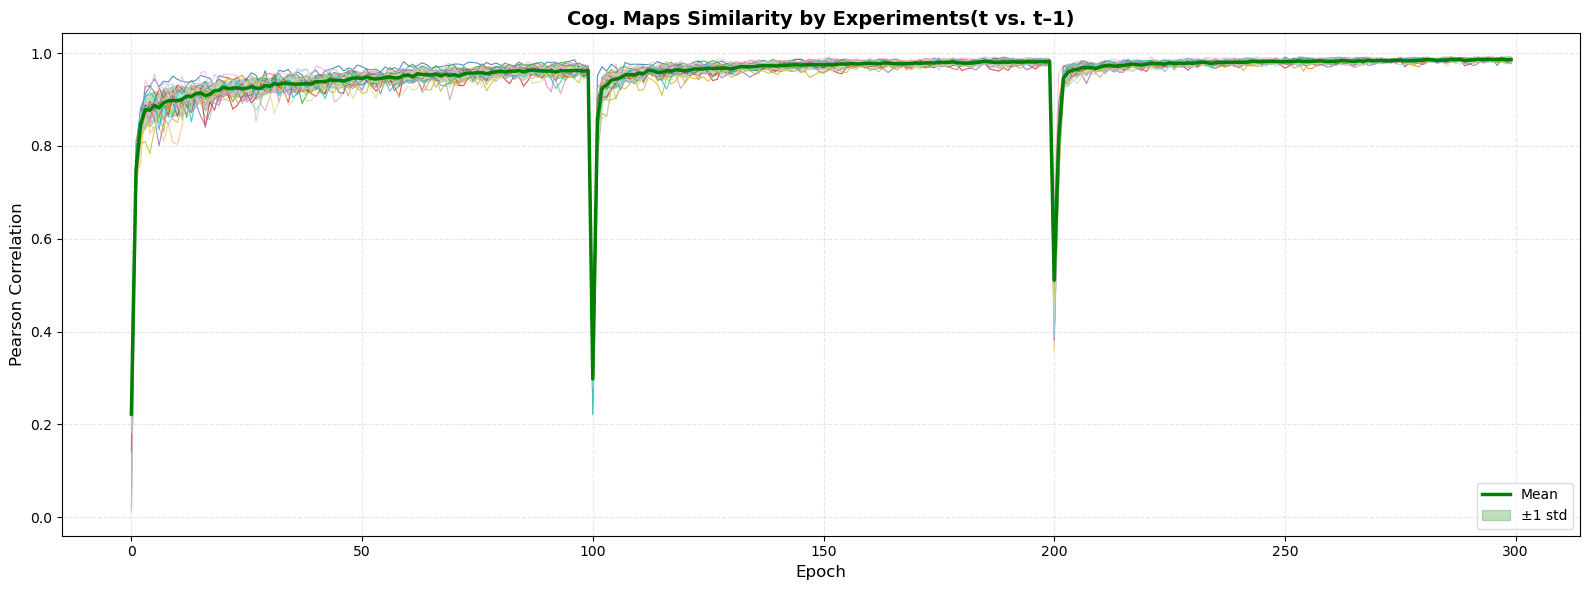

In [35]:
map_correlation_mean, map_correlation_std = compute_mean_std(all_correlation_history)
plot_cogmap_correlation(map_correlation_mean, map_correlation_std, figsize=(16,6))
plot_cogmap_correlation_by_experiment(all_correlation_history, figsize=(16,6))

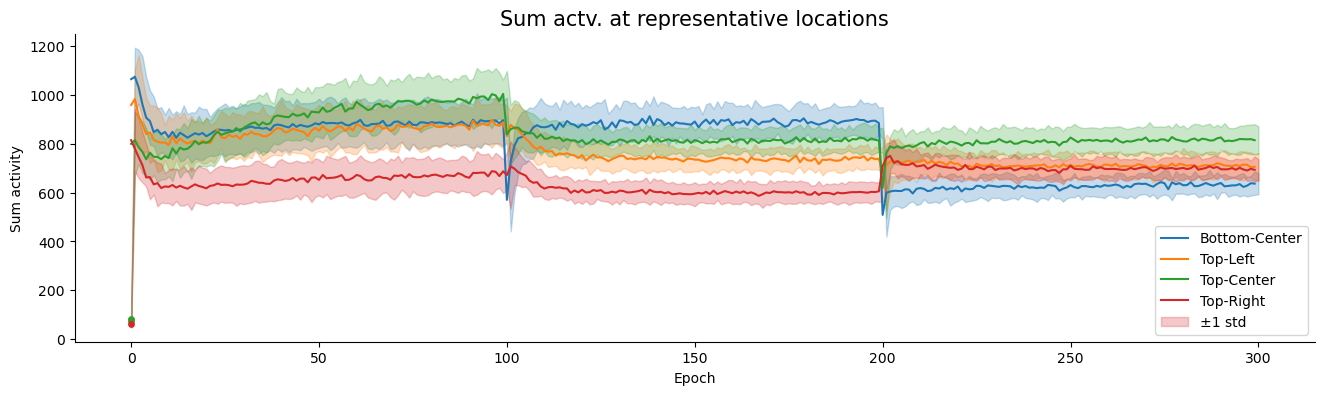

In [36]:
plot_activity_rep_loc(all_BC_rep_unit_sum_history, all_TL_rep_unit_sum_history, all_TC_rep_unit_sum_history, all_TR_rep_unit_sum_history, figsize=(16,4))

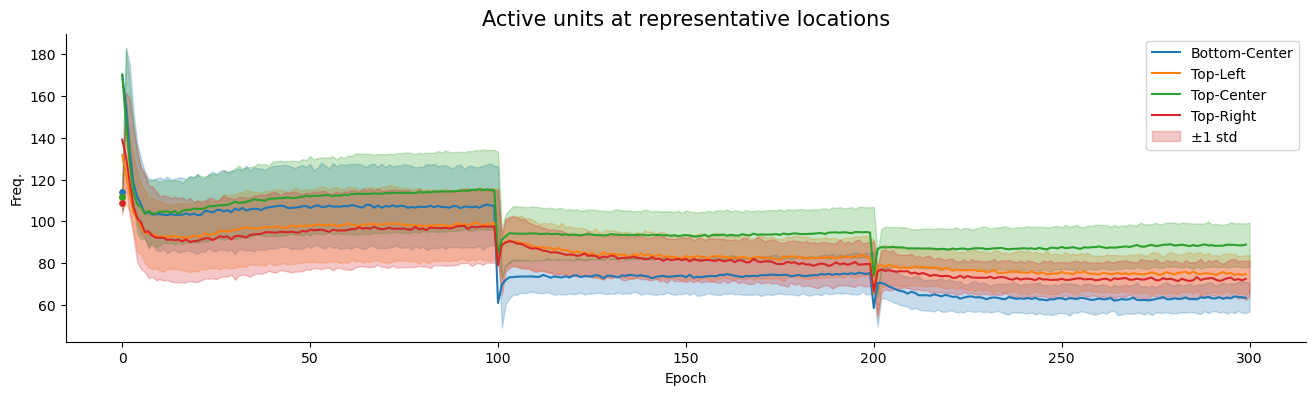

In [37]:
plot_units_rep_loc(all_BC_rep_unit_count_history, all_TL_rep_unit_count_history, all_TC_rep_unit_count_history, all_TR_rep_unit_count_history, figsize=(16,4))

In [39]:
mean_unit_coverage = [x * 100 for x in mean_unit_coverage_history] #Compute percentages

In [40]:
plot_active_units_count(num_active_units, figsize=(6,4))

TypeError: plot_active_units_count() missing 1 required positional argument: 'std'

In [ ]:
plot_unit_coverage(mean_unit_coverage, figsize=(6,4))

In [ ]:
plot_activity_rep_loc(BC_rep_unit_sum_history, TL_rep_unit_sum_history, TC_rep_unit_sum_history, TR_rep_unit_sum_history, figsize=(6,4))

In [ ]:
plot_units_rep_loc(BC_rep_unit_count_history, TL_rep_unit_count_history, TC_rep_unit_count_history, TR_rep_unit_count_history, figsize=(6,4))

In [ ]:
plot_cogmap_correlation(correlation_history, figsize=(6,4))